# 2D checkerboard in flow matching

This notebook contains a primary instantiaition of flow matching, the 2D checkerboard.

Dataset:2D checkboard
Model:MLP
Scheduler:CondOT

# Improts and init devices

In [1]:
import time
import torch

from torch import nn, Tensor

# flow_matching equivalents (local project)
from model.path.scheduler import CondOTScheduler
from model.path import AffineProbPath
from model.solver import ODESolver
from utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# To avoide meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
seed = 42
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Dataset

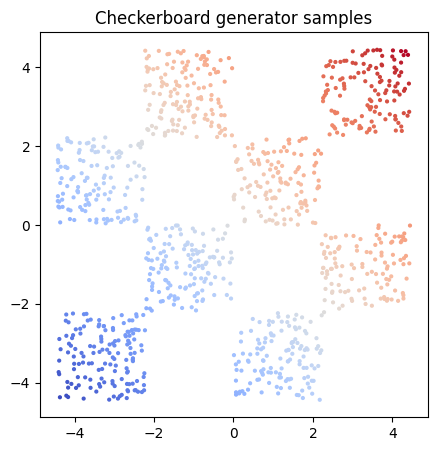

In [3]:
# Infinite generator matching the example checkerboard construction
def inf_train_gen(batch_size: int = 200, device: str = 'cpu'):
    # x1 uniform in [-2,2]
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    # second coord creates checkerboard pattern
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size,), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)

    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    return data.float()

# quick visualization of samples from the generator
samples = inf_train_gen(batch_size=1024, device='cpu').numpy()
plt.figure(figsize=(5,5))
plt.scatter(samples[:,0], samples[:,1], s=4, c=samples[:,0]+samples[:,1], cmap='coolwarm')
plt.title('Checkerboard generator samples')
plt.show()

# Model

In [4]:
# Activation and model definitions matching the example MLP
class Swish(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        return torch.sigmoid(x) * x

class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.main = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t], dim=1)
        output = self.main(h)
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, **extras):
        return self.model(x, t, **extras)

# instantiate model, scheduler and wrapper
vf = MLP(input_dim=2, time_dim=1, hidden_dim=128).to(device)
scheduler = CondOTScheduler()
path = AffineProbPath(scheduler=CondOTScheduler())
optim = torch.optim.Adam(vf.parameters(), lr=1e-3)
wrapper = WrappedModel(vf)

# Training

In [5]:
# training arguments
lr = 0.001
batch_size = 4096
iterations = 20001
print_every = 2000
hidden_dim = 512

# velocity field model already initialized as vf

optim = torch.optim.Adam(vf.parameters(), lr=lr)
start_time = time.time()
for i in range(iterations):
    optim.zero_grad()

    # sample data via generator
    x_1 = inf_train_gen(batch_size=batch_size, device=device)
    x_0 = torch.randn_like(x_1).to(device)

    # sample time
    t = torch.rand(x_1.shape[0], device=device)

    # sample probability path
    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # flow matching l2 loss
    loss = torch.pow(vf(path_sample.x_t, path_sample.t) - path_sample.dx_t, 2).mean()

    # optimizer step
    loss.backward()
    optim.step()

    # log loss
    if (i+1) % print_every == 0:
        elapsed = time.time() - start_time
        print('| iter {:6d} | {:5.2f} ms/step | loss {:8.3f} '.format(i+1, elapsed*1000/print_every, loss.item()))
        start_time = time.time()

| iter   2000 |  2.24 ms/step | loss    3.786 
| iter   4000 |  2.00 ms/step | loss    3.771 
| iter   6000 |  2.03 ms/step | loss    3.938 
| iter   8000 |  2.02 ms/step | loss    3.656 
| iter  10000 |  2.05 ms/step | loss    3.727 
| iter  12000 |  2.02 ms/step | loss    3.717 
| iter  14000 |  2.05 ms/step | loss    3.797 
| iter  16000 |  2.02 ms/step | loss    3.831 
| iter  18000 |  2.06 ms/step | loss    3.837 
| iter  20000 |  2.21 ms/step | loss    3.832 


# Wrap the trained velocity field for the ODE solver

In [6]:

wrapped_vf = WrappedModel(vf)

# step size for ode solver
step_size = 0.05
norm = cm.colors.Normalize(vmax=50, vmin=0)
batch_size = 50000
T = torch.linspace(0,1,10).to(device=device)
x_init = torch.randn((batch_size, 2), dtype=torch.float32, device=device)
solver = ODESolver(velocity_model=wrapped_vf)
sol = solver.sample(time_grid=T, x_init=x_init, method='midpoint', step_size=step_size, return_intermediates=True)
sol = sol.cpu().numpy()
T = T.cpu()

# Sampling with Implicit Euler (More Stable)

For stiff systems or better numerical stability, we can use implicit Euler method instead of explicit methods.


Sampling with explicit Euler (midpoint)...
Sampling with implicit Euler...
Explicit Euler solution shape: torch.Size([20, 10000, 2])
Implicit Euler solution shape: torch.Size([20, 10000, 2])


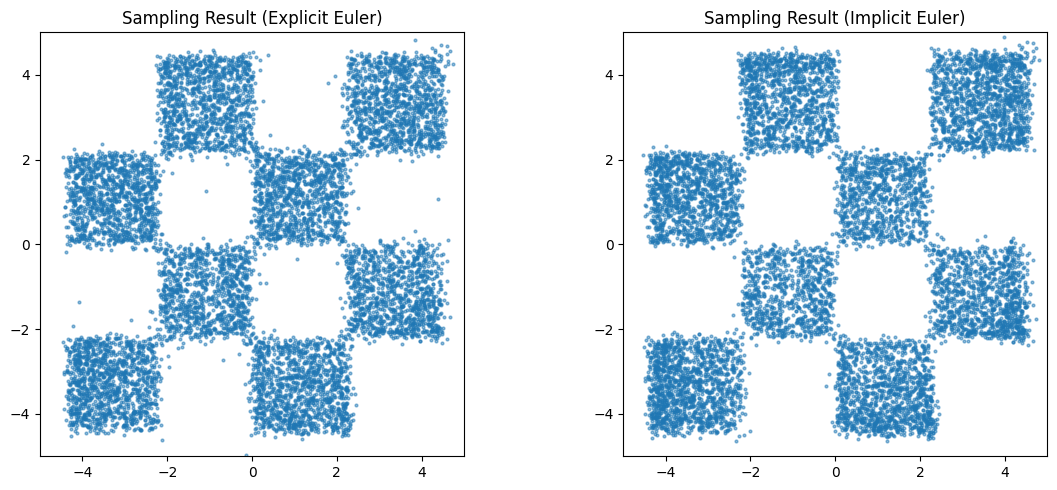

In [7]:
# Compare explicit vs implicit Euler sampling
wrapped_vf_implicit = WrappedModel(vf)

# Using implicit Euler for sampling
T_implicit = torch.linspace(0, 1, 20).to(device=device)
x_init_implicit = torch.randn((10000, 2), dtype=torch.float32, device=device)
solver_implicit = ODESolver(velocity_model=wrapped_vf_implicit)

print("Sampling with explicit Euler (midpoint)...")
sol_explicit = solver_implicit.sample(
    time_grid=T_implicit, 
    x_init=x_init_implicit, 
    method='midpoint', 
    step_size=0.05, 
    return_intermediates=True
)

print("Sampling with implicit Euler...")
sol_implicit = solver_implicit.sample(
    time_grid=T_implicit, 
    x_init=x_init_implicit, 
    method='implicit_euler', 
    return_intermediates=True
)

print("Explicit Euler solution shape:", sol_explicit.shape)
print("Implicit Euler solution shape:", sol_implicit.shape)

# Visualize comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Final distribution - Explicit Euler
axs[0].scatter(sol_explicit[-1, :, 0].cpu().numpy(), 
               sol_explicit[-1, :, 1].cpu().numpy(), 
               s=4, alpha=0.5)
axs[0].set_title('Sampling Result (Explicit Euler)')
axs[0].set_xlim(-5, 5)
axs[0].set_ylim(-5, 5)
axs[0].set_aspect('equal')

# Final distribution - Implicit Euler
axs[1].scatter(sol_implicit[-1, :, 0].cpu().numpy(), 
               sol_implicit[-1, :, 1].cpu().numpy(), 
               s=4, alpha=0.5)
axs[1].set_title('Sampling Result (Implicit Euler)')
axs[1].set_xlim(-5, 5)
axs[1].set_ylim(-5, 5)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# Visualize the path evolution as histograms

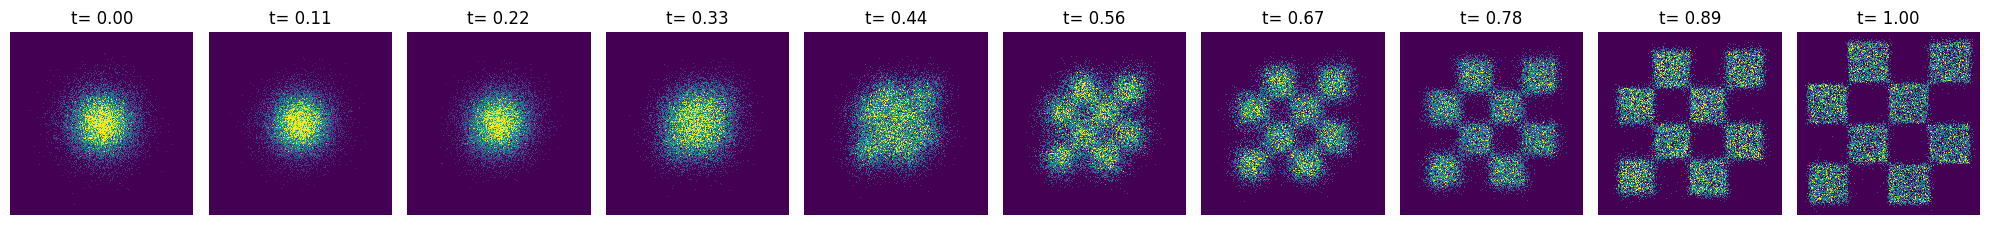

In [8]:

fig, axs = plt.subplots(1, 10, figsize=(20,20))
for i in range(10):
    H = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5),(-5,5)))
    cmin = 0.0
    cmax = torch.quantile(torch.from_numpy(H[0]), 0.99).item()
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    _ = axs[i].hist2d(sol[i,:,0], sol[i,:,1], 300, range=((-5,5),(-5,5)), norm=norm)
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    axs[i].set_title('t= %.2f' % (T[i]))
plt.tight_layout()
plt.show()

# Compute model likelihood using the solver's compute_likelihood method

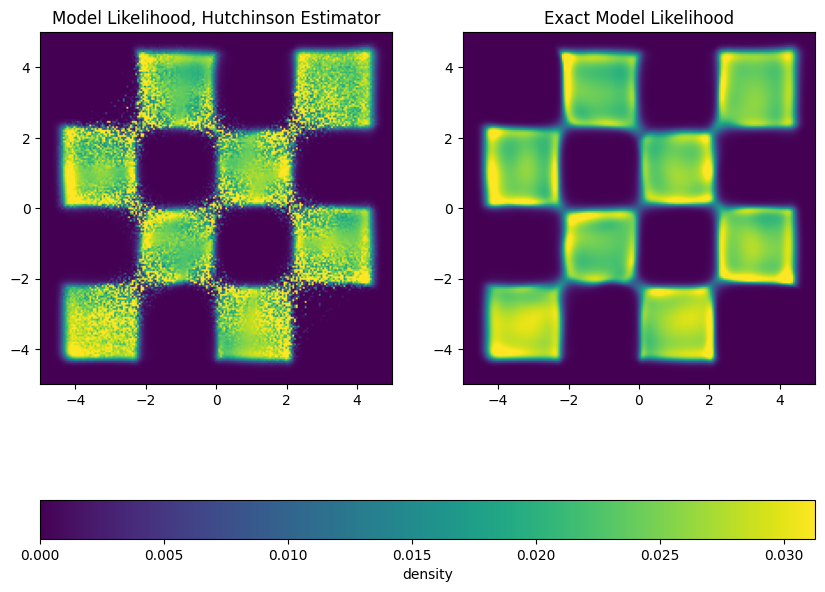

In [9]:

from torch.distributions import Independent, Normal
# source distribution is an isotropic gaussian
gaussian_log_density = Independent(Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1).log_prob
# compute log likelihood with unbiased hutchinson estimator, average over num_acc
num_acc = 5
log_p_acc = 0
grid_size = 200
x_1 = torch.meshgrid(torch.linspace(-5, 5, grid_size), torch.linspace(-5, 5, grid_size))
x_1 = torch.stack([x_1[0].flatten(), x_1[1].flatten()], dim=1).to(device)
for i in range(num_acc):
    _, log_p = solver.compute_likelihood(x_1=x_1, method='midpoint', step_size=step_size, exact_divergence=False, log_p0=gaussian_log_density)
    log_p_acc += log_p
log_p_acc /= num_acc
_, exact_log_p = solver.compute_likelihood(x_1=x_1, method='midpoint', step_size=step_size, exact_divergence=True, log_p0=gaussian_log_density)
likelihood = torch.exp(log_p_acc).cpu().reshape(grid_size, grid_size).detach().numpy()
exact_likelihood = torch.exp(exact_log_p).cpu().reshape(grid_size, grid_size).detach().numpy()
fig, axs = plt.subplots(1, 2, figsize=(10,10))
cmin = 0.0
cmax = 1/32
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
axs[0].imshow(likelihood, extent=(-5,5,-5,5), origin='lower', cmap='viridis', norm=norm)
axs[0].set_title('Model Likelihood, Hutchinson Estimator')
axs[1].imshow(exact_likelihood, extent=(-5,5,-5,5), origin='lower', cmap='viridis', norm=norm)
axs[1].set_title('Exact Model Likelihood')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs, orientation='horizontal', label='density')
plt.show()